<a href="https://colab.research.google.com/github/javageek2018/AirlineArrivalDelay/blob/main/notebooks/06_gradient_boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XGBoost Model Training

# Imports

In [10]:
from pyspark.sql.functions import col
import pyspark
import os
from pyspark.sql import SparkSession
from pyspark.sql import Window
from pyspark.sql import functions as F
import shutil, os, glob

from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from xgboost.spark import SparkXGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math

import numpy as np
from pyspark.sql.types import DoubleType

import urllib.request

# Mount Google Drive

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Set Up Spark

In [12]:
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

In [13]:
# spark = SparkSession.builder \
#     .appName("ColabSpark") \
#     .master("local[*]") \
#     .config("spark.driver.memory", "8g") \
#     .getOrCreate()

# spark


spark = SparkSession.builder \
    .appName("FlightDelayXGB") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark

# Read Data (Spark)

In [14]:
spark.conf.set("spark.sql.parquet.int96RebaseModeInRead", "CORRECTED")
spark.conf.set("spark.sql.legacy.parquet.nanosAsLong", "true")

In [15]:
# base_path = "/content/drive/MyDrive/OMDS Capstone/Data/flights_all_features_encoded"

# base_path = "/content/drive/MyDrive/flight_data"

# train_file_path = f"{base_path}/train.parquet"
# validate_file_path = f"{base_path}/val.parquet"
# test_file_path = f"{base_path}/test.parquet"


# df_train = spark.read.parquet(train_file_path)
# df_val = spark.read.parquet(validate_file_path)
# df_test = spark.read.parquet(test_file_path)

In [16]:
BASE_PATH  = '/content/drive/MyDrive/flight_data'
ZENODO_URL = 'https://zenodo.org/records/20489802/files'

os.makedirs(BASE_PATH, exist_ok=True)

for filename in ['train.parquet', 'val.parquet', 'test.parquet']:
    local_path = f'{BASE_PATH}/{filename}'
    if not os.path.exists(local_path):
        print(f'Downloading {filename}...')
        urllib.request.urlretrieve(f'{ZENODO_URL}/{filename}?download=1', local_path)
        print(f'  Done: {local_path}')
    else:
        print(f'Found: {local_path}')

  Done: /content/drive/MyDrive/flight_data/train.parquet
  Done: /content/drive/MyDrive/flight_data/val.parquet
  Done: /content/drive/MyDrive/flight_data/test.parquet


In [19]:
train_file_path    = f'{BASE_PATH}/train.parquet'
validate_file_path = f'{BASE_PATH}/val.parquet'
test_file_path     = f'{BASE_PATH}/test.parquet'

In [20]:
df_train = spark.read.parquet(train_file_path)
df_val = spark.read.parquet(validate_file_path)
df_test = spark.read.parquet(test_file_path)

In [21]:
print(f"Train: {df_train.count():,} rows")
print(f"Val  : {df_val.count():,} rows")
print(f"Test : {df_test.count():,} rows")

Train: 31,149,502 rows
Val  : 6,743,403 rows
Test : 6,965,246 rows


## Sample the Data

In [22]:
print("📅 Year ranges:")
df_train.select(F.min('Year'), F.max('Year')).show()
df_val.select(F.min('Year'), F.max('Year')).show()
df_test.select(F.min('Year'), F.max('Year')).show()

📅 Year ranges:
+---------+---------+
|min(Year)|max(Year)|
+---------+---------+
|     2018|     2022|
+---------+---------+

+---------+---------+
|min(Year)|max(Year)|
+---------+---------+
|     2023|     2023|
+---------+---------+

+---------+---------+
|min(Year)|max(Year)|
+---------+---------+
|     2024|     2024|
+---------+---------+



In [23]:
SAMPLE_FRACTION = 0.20   # tune based on Colab RAM

# Build stratification key: Year × Month × Class
df_train_keyed = df_train.withColumn(
    'strat_key',
    F.concat_ws('_',
        F.col('Year').cast('string'),
        F.col('Month').cast('string'),
        F.col('ArrDel15').cast('string')
    )
)

# Get all unique strata (5 years × 12 months × 2 classes = 120 strata)
strata = [row['strat_key'] for row in
          df_train_keyed.select('strat_key').distinct().collect()]

print(f"Number of strata: {len(strata)}")

# Same fraction for every stratum
fractions = {s: SAMPLE_FRACTION for s in strata}

# Sample
df_train_sampled = (
    df_train_keyed
    .sampleBy('strat_key', fractions=fractions, seed=42)
    .drop('strat_key')
)

Number of strata: 120


In [24]:
df_train_sampled = df_train_sampled.cache()
df_val_full      = df_val.cache()         # keep val full
df_test_full     = df_test.cache()        # keep test full

# Force materialization (also gives you counts)
train_n = df_train_sampled.count()
val_n   = df_val_full.count()
test_n  = df_test_full.count()

print(f"Train (sampled): {train_n:,}")
print(f"Val   (full 2023): {val_n:,}")
print(f"Test  (full 2024): {test_n:,}")

Train (sampled): 6,232,006
Val   (full 2023): 6,743,403
Test  (full 2024): 6,965,246


In [25]:
# Sample val to ~1M for fast early-stopping evaluation
df_val_sampled = df_val.sampleBy(
    'ArrDel15',
    fractions={0: 0.15, 1: 0.15},   # ~15% → ~1M rows
    seed=42
).cache()

print(f"Val sampled: {df_val_sampled.count():,}")

Val sampled: 1,013,595


## Add Interaction Features

In [26]:
def add_weather_features(df):
    return (df
        # Compounding severe weather (both ends)
        .withColumn('both_severe_weather',
                    F.col('origin_severe_weather') * F.col('dest_severe_weather'))

        # Snow + low visibility = grounding risk
        .withColumn('snow_lowvis_origin',
                    F.col('origin_is_snow') * F.col('origin_low_visibility'))

        # Total weather severity score
        .withColumn('weather_severity_score',
                    F.col('origin_severe_weather') * 3 +
                    F.col('origin_is_snow') * 2 +
                    F.col('origin_is_rain') +
                    F.col('origin_low_visibility') +
                    F.col('origin_high_wind') +
                    F.col('dest_severe_weather') * 3 +
                    F.col('dest_is_snow') * 2)

        # Wind speed × precipitation (storm intensity)
        .withColumn('origin_storm_intensity',
                    F.col('origin_wind_kts') * F.col('origin_precip_in'))
        .withColumn('dest_storm_intensity',
                    F.col('dest_wind_kts') * F.col('dest_precip_in'))
    )

df_train_sampled = add_weather_features(df_train_sampled)
df_val_sampled   = add_weather_features(df_val_sampled)
df_test          = add_weather_features(df_test)

# Train Model

## Define Columns

In [27]:
target = 'ArrDel15'

drop_cols = [
    'FlightDate', 'date',
    'Flight_Number_Reporting_Airline',
    'origin_wx_codes', 'dest_wx_codes',
    target
]

categorical_cols = ['Reporting_Airline', 'Origin', 'Dest', 'DepTimeBlk']

# All numeric columns (everything else except target/drops/categoricals)
all_cols = [c for c, _ in df_train.dtypes]
numeric_cols = [c for c in all_cols if c not in drop_cols + categorical_cols]

In [28]:
def add_interaction_features(df):
    return (df
        .withColumn('hour_x_month',         F.col('dep_hour') * F.col('Month'))
        .withColumn('hour_x_dow',           F.col('dep_hour') * F.col('DayOfWeek'))
        .withColumn('wind_x_rain',          F.col('origin_wind_kts') * F.col('origin_is_rain'))
        .withColumn('lowvis_x_rain',        F.col('origin_low_visibility') * F.col('origin_is_rain'))
        .withColumn('combined_severe',      F.col('origin_severe_weather') + F.col('dest_severe_weather'))
        .withColumn('dep_per_hour_x_hour',  F.col('origin_departures_3h') * F.col('dep_hour'))
        .withColumn('combined_route_risk',  F.col('origin_delay_rate_30d') * F.col('dest_delay_rate_30d'))
        .withColumn('carrier_route_risk',   F.col('carrier_delay_rate_30d') * F.col('origin_delay_rate_30d'))
        .withColumn('holiday_x_hour',       F.col('is_holiday') * F.col('dep_hour'))
        .withColumn('is_longhaul',          (F.col('Distance') > 1500).cast('int'))
    )

df_train_sampled = add_interaction_features(df_train_sampled)
df_val_sampled   = add_interaction_features(df_val_sampled)
df_test          = add_interaction_features(df_test)

# Add to numeric features
NEW_FEATURES = ['hour_x_month', 'hour_x_dow', 'wind_x_rain', 'lowvis_x_rain',
                'combined_severe', 'dep_per_hour_x_hour', 'combined_route_risk',
                'carrier_route_risk', 'holiday_x_hour', 'is_longhaul']
numeric_cols = numeric_cols + NEW_FEATURES
feature_cols = numeric_cols + [f"{c}_idx" for c in categorical_cols]

In [29]:
# Average route delay for each (Origin, Dest) pair — from training data only
route_stats = (
    df_train_sampled
    .groupBy('Origin', 'Dest')
    .agg(
        F.avg(F.col(target).cast('double')).alias('route_delay_rate'),
        F.count('*').alias('route_n_flights')
    )
    .filter(F.col('route_n_flights') >= 30)
)

# Join into all splits
df_train_sampled = df_train_sampled.join(route_stats, ['Origin', 'Dest'], 'left')
df_val_sampled   = df_val_sampled.join(route_stats, ['Origin', 'Dest'], 'left')
df_test          = df_test.join(route_stats, ['Origin', 'Dest'], 'left')

# Fill nulls with global mean (for unseen routes)
global_rate = df_train_sampled.agg(F.avg(target)).collect()[0][0]
for d in [df_train_sampled, df_val_sampled, df_test]:
    d = d.fillna({'route_delay_rate': global_rate, 'route_n_flights': 0})

# Add to NUMERIC_COLS
numeric_cols += ['route_delay_rate', 'route_n_flights']
FEATURE_COLS = numeric_cols + [f"{c}_idx" for c in categorical_cols]

In [30]:
df_train_sampled.dtypes

[('Origin', 'string'),
 ('Dest', 'string'),
 ('Year', 'bigint'),
 ('Quarter', 'bigint'),
 ('Month', 'bigint'),
 ('DayofMonth', 'bigint'),
 ('DayOfWeek', 'bigint'),
 ('FlightDate', 'bigint'),
 ('Reporting_Airline', 'string'),
 ('Flight_Number_Reporting_Airline', 'string'),
 ('CRSDepTime', 'bigint'),
 ('DepTimeBlk', 'string'),
 ('CRSArrTime', 'bigint'),
 ('ArrDel15', 'bigint'),
 ('CRSElapsedTime', 'double'),
 ('Distance', 'double'),
 ('DistanceGroup', 'bigint'),
 ('date', 'string'),
 ('dep_hour', 'bigint'),
 ('arr_hour', 'bigint'),
 ('dep_hour_minus2', 'bigint'),
 ('arr_hour_minus2', 'bigint'),
 ('origin_temp_f', 'double'),
 ('origin_dewpoint_f', 'double'),
 ('origin_humidity', 'double'),
 ('origin_feels_like_f', 'double'),
 ('origin_wind_kts', 'double'),
 ('origin_gust_kts', 'double'),
 ('origin_visibility', 'double'),
 ('origin_precip_in', 'double'),
 ('origin_wx_codes', 'string'),
 ('origin_is_rain', 'int'),
 ('origin_is_snow', 'int'),
 ('origin_is_fog', 'int'),
 ('origin_low_visibili

## Check for NULLs and Cast Target

In [31]:
total = df_train_sampled.count()
null_row = df_train_sampled.select([
    F.sum(F.col(c).isNull().cast('int')).alias(c)
    for c in numeric_cols
]).collect()[0].asDict()

nulls_found = {c: n for c, n in null_row.items() if n > 0}

if not nulls_found:
    print("✅ No nulls in any numeric column.")
else:
    print(f"⚠️ {len(nulls_found)} columns with nulls:")
    for c, n in sorted(nulls_found.items(), key=lambda x: -x[1]):
        print(f"  {c:<35} {n:>10,}  ({100*n/total:.2f}%)")

⚠️ 2 columns with nulls:
  route_delay_rate                        15,948  (0.26%)
  route_n_flights                         15,948  (0.26%)


In [32]:
def prep(df):
    # Cast target to int (XGBoost requires integer labels for classification)
    df = df.withColumn(target, F.col(target).cast('int'))

    # Cast all numeric features to double for VectorAssembler consistency
    for c in numeric_cols:
        df = df.withColumn(c, F.col(c).cast('double'))

    return df

df_train_sampled = prep(df_train_sampled)
df_val_sampled   = prep(df_val_sampled)
df_test  = prep(df_test)

## Index Categoricals (Spark ML)

In [33]:
# XGBoost handles integer-encoded categoricals well, and one-hot explodes dimensionality

indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid='keep'   # unseen categories → extra bucket
    )
    for c in categorical_cols
]

## Assemble Feature Vector

In [34]:
# Fill any nulls with 0 for all numeric features
df_train_sampled = df_train_sampled.fillna(0.0, subset=numeric_cols)
df_val_sampled   = df_val_sampled.fillna(0.0,   subset=numeric_cols)
df_test          = df_test.fillna(0.0,          subset=numeric_cols)

# Then VectorAssembler can use strict mode
assembler = VectorAssembler(
    inputCols=FEATURE_COLS,
    outputCol='features',
    handleInvalid='error'
)

In [35]:
feature_cols = numeric_cols + [f"{c}_idx" for c in categorical_cols]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol='features',
    handleInvalid='keep'
)

## Calculate Hyperparameter for Class Imbalance


In [36]:
counts = df_train_sampled.groupBy(target).count().collect()
counts_dict = {row[target]: row['count'] for row in counts}
# scale_pos_weight = math.sqrt(counts_dict[0] / counts_dict[1])
scale_pos_weight = 1 # makes the model more conservative
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

scale_pos_weight = 1.00


In [37]:
# Year distribution
print("📅 Sampled train by year:")
df_train_sampled.groupBy('Year').count().orderBy('Year').show()

# Month distribution
print("📆 Sampled train by month:")
df_train_sampled.groupBy('Month').count().orderBy('Month').show()

# Compare delay rates: original vs sample
orig_rate = df_train.filter(F.col('ArrDel15')==1).count() / df_train.count()
samp_rate = counts_dict[1] / (counts_dict[0] + counts_dict[1])

print(f"\nOriginal delay rate: {orig_rate:.4f}")
print(f"Sample   delay rate: {samp_rate:.4f}")
print(f"Diff               : {abs(orig_rate - samp_rate)*100:.3f}%  ← should be < 0.1%")

📅 Sampled train by year:
+------+-------+
|  Year|  count|
+------+-------+
|2018.0|1415135|
|2019.0|1452412|
|2020.0| 881133|
|2021.0|1176829|
|2022.0|1306497|
+------+-------+

📆 Sampled train by month:
+-----+------+
|Month| count|
+-----+------+
|  1.0|515985|
|  2.0|476455|
|  3.0|548052|
|  4.0|470669|
|  5.0|491727|
|  6.0|510192|
|  7.0|556227|
|  8.0|554320|
|  9.0|514856|
| 10.0|542109|
| 11.0|524723|
| 12.0|526691|
+-----+------+


Original delay rate: 0.1785
Sample   delay rate: 0.1784
Diff               : 0.007%  ← should be < 0.1%


## Configure Spark XGBoost Classifier

In [38]:
xgb_clf = SparkXGBClassifier(
    features_col='features',
    label_col=target,
    prediction_col='prediction',
    probability_col='probability',
    raw_prediction_col='rawPrediction',

    # Hyperparameters
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=10,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.05,
    #reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    tree_method='hist',
    max_bin=256,

    # Distributed training
    num_workers=1,           # set to # of Spark executors
    device='cuda',            # or 'cuda' for GPU
    early_stopping_rounds=100,
    validation_indicator_col='is_val'
)

## Combine Train + Val for Early Stopping

In [39]:
# df_train_marked = df_train.withColumn('is_val', F.lit(False))
# df_val_marked   = df_val.withColumn('is_val', F.lit(True))
# df_trainval     = df_train_marked.unionByName(df_val_marked)

# Use SAMPLED val for early stopping (faster)
# Or use df_val_full if you have RAM headroom

df_train_marked = df_train_sampled.withColumn('is_val', F.lit(False))
df_val_marked   = df_val_sampled.withColumn('is_val', F.lit(True))   # or df_val_full

df_trainval = df_train_marked.unionByName(df_val_marked).repartition(8).cache()

print(f"Combined train+val: {df_trainval.count():,}")
print(f"Train rows: {df_trainval.filter(~F.col('is_val')).count():,}")
print(f"Val   rows: {df_trainval.filter( F.col('is_val')).count():,}")

Combined train+val: 7,245,601
Train rows: 6,232,006
Val   rows: 1,013,595


## Build and Fit Pipeline

In [40]:
pipeline = Pipeline(stages=indexers + [assembler, xgb_clf])

model = pipeline.fit(df_trainval)
print("✅ Training complete")

INFO:XGBoost-PySpark:Running xgboost-3.2.0 on 1 workers with
	booster params: {'objective': 'binary:logistic', 'colsample_bytree': 0.8, 'device': 'cuda', 'eval_metric': 'auc', 'gamma': 0.05, 'learning_rate': 0.03, 'max_bin': 256, 'max_depth': 10, 'min_child_weight': 3, 'reg_lambda': 1.0, 'scale_pos_weight': 1, 'subsample': 0.8, 'tree_method': 'hist', 'nthread': 1}
	train_call_kwargs_params: {'early_stopping_rounds': 100, 'verbose_eval': True, 'num_boost_round': 3000}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!


✅ Training complete


# Evaluate on Validation Set

In [41]:
preds = model.transform(df_val_sampled)

# ROC-AUC & PR-AUC
auc_eval = BinaryClassificationEvaluator(
    labelCol=target, rawPredictionCol='rawPrediction', metricName='areaUnderROC'
)
pr_eval = BinaryClassificationEvaluator(
    labelCol=target, rawPredictionCol='rawPrediction', metricName='areaUnderPR'
)

print(f"ROC-AUC: {auc_eval.evaluate(preds):.4f}")
print(f"PR-AUC : {pr_eval.evaluate(preds):.4f}")

# Accuracy / F1
acc_eval = MulticlassClassificationEvaluator(
    labelCol=target, predictionCol='prediction', metricName='accuracy'
)
f1_eval = MulticlassClassificationEvaluator(
    labelCol=target, predictionCol='prediction', metricName='f1'
)
print(f"Accuracy: {acc_eval.evaluate(preds):.4f}")
print(f"F1      : {f1_eval.evaluate(preds):.4f}")

# Confusion matrix
preds.groupBy(target, 'prediction').count().orderBy(target, 'prediction').show()

ROC-AUC: 0.7142
PR-AUC : 0.4118
Accuracy: 0.8016
F1      : 0.7508
+--------+----------+------+
|ArrDel15|prediction| count|
+--------+----------+------+
|       0|       0.0|782852|
|       0|       1.0| 22312|
|       1|       0.0|178764|
|       1|       1.0| 29667|
+--------+----------+------+



## Confusion Matrix at 50/50 Threshold

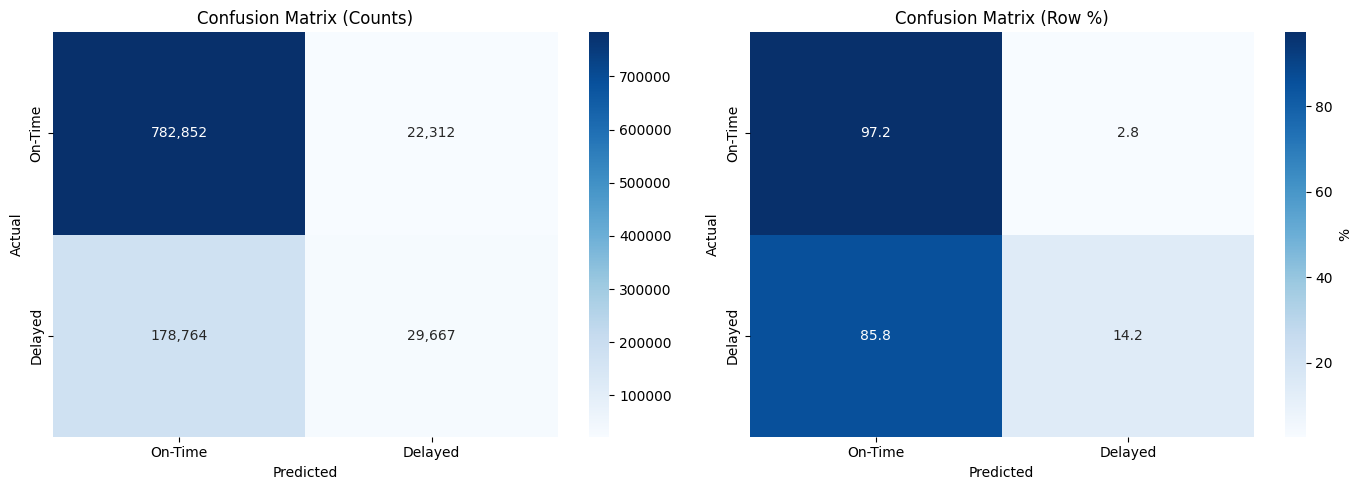

In [42]:
cm_pd = (preds.groupBy(target, 'prediction').count()
              .toPandas()
              .pivot(index=target, columns='prediction', values='count')
              .fillna(0).astype(int))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm_pd, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
            xticklabels=['On-Time', 'Delayed'],
            yticklabels=['On-Time', 'Delayed'])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Row-normalized (recall view)
cm_pct = cm_pd.div(cm_pd.sum(axis=1), axis=0) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            xticklabels=['On-Time', 'Delayed'],
            yticklabels=['On-Time', 'Delayed'],
            cbar_kws={'label': '%'})
axes[1].set_title('Confusion Matrix (Row %)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Threshold Tuning (Decision rule on flight delay probabilities, where are we drawing the line to consider a flight as delayed)



In [43]:
from pyspark.sql.types import DoubleType

# Extract P(class=1) from probability vector
extract_p1 = F.udf(lambda v: float(v[1]), DoubleType())
preds_with_p = preds.withColumn('p1', extract_p1('probability'))

# Sweep thresholds
import numpy as np
results = []
for t in np.arange(0.2, 0.8, 0.05):
    tp = preds_with_p.filter((F.col('p1') >= t) & (F.col(target) == 1)).count()
    fp = preds_with_p.filter((F.col('p1') >= t) & (F.col(target) == 0)).count()
    fn = preds_with_p.filter((F.col('p1') <  t) & (F.col(target) == 1)).count()
    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1   = 2 * prec * rec / (prec + rec + 1e-9)
    results.append((round(t,2), prec, rec, f1))

for r in results:
    print(f"thr={r[0]:.2f} | P={r[1]:.3f} | R={r[2]:.3f} | F1={r[3]:.3f}")

thr=0.20 | P=0.333 | R=0.649 | F1=0.440
thr=0.25 | P=0.376 | R=0.527 | F1=0.439
thr=0.30 | P=0.417 | R=0.422 | F1=0.420
thr=0.35 | P=0.456 | R=0.333 | F1=0.385
thr=0.40 | P=0.495 | R=0.258 | F1=0.339
thr=0.45 | P=0.532 | R=0.194 | F1=0.285
thr=0.50 | P=0.571 | R=0.142 | F1=0.228
thr=0.55 | P=0.611 | R=0.101 | F1=0.174
thr=0.60 | P=0.650 | R=0.069 | F1=0.124
thr=0.65 | P=0.692 | R=0.044 | F1=0.083
thr=0.70 | P=0.738 | R=0.026 | F1=0.051
thr=0.75 | P=0.783 | R=0.014 | F1=0.028
thr=0.80 | P=0.827 | R=0.007 | F1=0.014


## Feature Importance

In [44]:
xgb_model = model.stages[-1]
booster = xgb_model.get_booster()
importance = booster.get_score(importance_type='gain')

# Map integer-string keys to feature names
imp_named = sorted(
    [(feature_cols[int(k)], v) for k, v in importance.items()],
    key=lambda x: -x[1]
)

print(f"{'Feature':<40}{'Gain':>12}")
print("-" * 52)
for feat, score in imp_named[:25]:
    print(f"{feat:<40}{score:>12.2f}")

Feature                                         Gain
----------------------------------------------------
combined_severe                               546.73
arr_hour_minus2                               268.06
origin_is_snow                                216.16
dep_hour_minus2                               188.40
origin_severe_weather                          91.79
combined_route_risk                            63.95
carrier_route_risk                             61.04
dest_severe_weather                            44.92
origin_precip_in                               36.57
Month                                          33.06
origin_low_visibility                          32.57
Quarter                                        30.69
route_delay_rate                               30.41
CRSDepTime                                     29.51
Reporting_Airline_idx                          29.19
carrier_delay_rate_30d                         27.68
dest_precip_in                                

In [45]:
# How many features actually used vs total?
used_features = len(importance)
total_features = len(feature_cols)
print(f"Used: {used_features} / {total_features} ({100*used_features/total_features:.1f}%)")

# Show ALL features sorted (including unused)
all_imp = {f: 0.0 for f in feature_cols}
for k, v in importance.items():
    all_imp[feature_cols[int(k)]] = v

sorted_all = sorted(all_imp.items(), key=lambda x: -x[1])
print("\nAll features ranked:")
for f, s in sorted_all:
    bar = '█' * int(s / 5) if s > 0 else ''
    print(f"  {f:<35}{s:>10.2f}  {bar}")

Used: 71 / 71 (100.0%)

All features ranked:
  combined_severe                        546.73  █████████████████████████████████████████████████████████████████████████████████████████████████████████████
  arr_hour_minus2                        268.06  █████████████████████████████████████████████████████
  origin_is_snow                         216.16  ███████████████████████████████████████████
  dep_hour_minus2                        188.40  █████████████████████████████████████
  origin_severe_weather                   91.79  ██████████████████
  combined_route_risk                     63.95  ████████████
  carrier_route_risk                      61.04  ████████████
  dest_severe_weather                     44.92  ████████
  origin_precip_in                        36.57  ███████
  Month                                   33.06  ██████
  origin_low_visibility                   32.57  ██████
  Quarter                                 30.69  ██████
  route_delay_rate                    

In [46]:
# Are the historical delay rates really computed correctly?
df_train_sampled.select(
    F.mean('carrier_delay_rate_30d').alias('carrier_30d_mean'),
    F.stddev('carrier_delay_rate_30d').alias('carrier_30d_std'),
    F.mean('origin_delay_rate_30d').alias('origin_30d_mean'),
    F.mean('dest_delay_rate_30d').alias('dest_30d_mean'),
).show()

# Check for null/zero variance
df_train_sampled.select(
    F.sum(F.col('carrier_delay_rate_30d').isNull().cast('int')).alias('carrier_nulls'),
    F.sum(F.col('origin_delay_rate_30d').isNull().cast('int')).alias('origin_nulls'),
).show()

+-----------------+-----------------+-------------------+-------------------+
| carrier_30d_mean|  carrier_30d_std|    origin_30d_mean|      dest_30d_mean|
+-----------------+-----------------+-------------------+-------------------+
|0.177985132306443|0.067065662187449|0.17792439187305428|0.17801978893297235|
+-----------------+-----------------+-------------------+-------------------+

+-------------+------------+
|carrier_nulls|origin_nulls|
+-------------+------------+
|            0|           0|
+-------------+------------+



## Determine threshold

In [47]:
OPTIMAL_THRESHOLD = 0.20

preds_final = preds_with_p.withColumn(
    'final_prediction',
    (F.col('p1') >= OPTIMAL_THRESHOLD).cast('double')
)

# Confusion matrix at chosen threshold
preds_final.groupBy(target, 'final_prediction').count().orderBy(target, 'final_prediction').show()

+--------+----------------+------+
|ArrDel15|final_prediction| count|
+--------+----------------+------+
|       0|             0.0|534564|
|       0|             1.0|270600|
|       1|             0.0| 73247|
|       1|             1.0|135184|
+--------+----------------+------+



In [48]:
for t in np.arange(0.10, 0.30, 0.02):
    tp = preds_with_p.filter((F.col('p1') >= t) & (F.col(target) == 1)).count()
    fp = preds_with_p.filter((F.col('p1') >= t) & (F.col(target) == 0)).count()
    fn = preds_with_p.filter((F.col('p1') <  t) & (F.col(target) == 1)).count()
    tn = preds_with_p.filter((F.col('p1') <  t) & (F.col(target) == 0)).count()

    prec = tp/(tp+fp+1e-9); rec = tp/(tp+fn+1e-9)
    f1 = 2*prec*rec/(prec+rec+1e-9); acc = (tp+tn)/(tp+fp+fn+tn)
    print(f"thr={t:.2f} | P={prec:.3f} | R={rec:.3f} | F1={f1:.3f} | Acc={acc:.3f}")

thr=0.10 | P=0.244 | R=0.917 | F1=0.385 | Acc=0.398
thr=0.12 | P=0.261 | R=0.867 | F1=0.401 | Acc=0.468
thr=0.14 | P=0.279 | R=0.813 | F1=0.416 | Acc=0.530
thr=0.16 | P=0.297 | R=0.758 | F1=0.427 | Acc=0.582
thr=0.18 | P=0.315 | R=0.702 | F1=0.435 | Acc=0.625
thr=0.20 | P=0.333 | R=0.649 | F1=0.440 | Acc=0.661
thr=0.22 | P=0.351 | R=0.598 | F1=0.442 | Acc=0.690
thr=0.24 | P=0.368 | R=0.550 | F1=0.441 | Acc=0.713
thr=0.26 | P=0.384 | R=0.505 | F1=0.436 | Acc=0.732
thr=0.28 | P=0.400 | R=0.462 | F1=0.429 | Acc=0.747


## Final Validation Set Metrics

In [49]:
T = 0.22  # chosen operating point
tp = preds_with_p.filter((F.col('p1') >= T) & (F.col(target) == 1)).count()
fp = preds_with_p.filter((F.col('p1') >= T) & (F.col(target) == 0)).count()
fn = preds_with_p.filter((F.col('p1') <  T) & (F.col(target) == 1)).count()
tn = preds_with_p.filter((F.col('p1') <  T) & (F.col(target) == 0)).count()

prec = tp/(tp+fp); rec = tp/(tp+fn)
spec = tn/(tn+fp); f1 = 2*prec*rec/(prec+rec)
acc = (tp+tn)/(tp+fp+fn+tn)

print(f"\n=== FINAL METRICS @ threshold={T} ===")
print(f"Accuracy   : {acc:.4f}")
print(f"Precision  : {prec:.4f}")
print(f"Recall     : {rec:.4f}")
print(f"Specificity: {spec:.4f}")
print(f"F1         : {f1:.4f}")
print(f"\nCaught {tp:,} of {tp+fn:,} delays ({rec*100:.1f}%)")
print(f"Falsely flagged {fp:,} on-time flights ({fp/(fp+tn)*100:.1f}% FPR)")


=== FINAL METRICS @ threshold=0.22 ===
Accuracy   : 0.6895
Precision  : 0.3506
Recall     : 0.5982
Specificity: 0.7132
F1         : 0.4421

Caught 124,679 of 208,431 delays (59.8%)
Falsely flagged 230,919 on-time flights (28.7% FPR)


## Audit Features

In [50]:
def audit_model_features(model, target_features):
    """Audit whether specific features are used by the trained model."""

    # Find the VectorAssembler specifically (not StringIndexers)
    from pyspark.ml.feature import VectorAssembler

    assembler = None
    for s in model.stages:
        if isinstance(s, VectorAssembler):
            assembler = s
            break

    if assembler is None:
        print("❌ No VectorAssembler found in pipeline")
        return

    actual_features = assembler.getInputCols()

    # Get XGBoost importance
    booster = model.stages[-1].get_booster()
    importance = booster.get_score(importance_type='gain')

    used_indices = {int(k) for k in importance.keys()}
    feature_gain = {actual_features[int(k)]: v for k, v in importance.items()}

    # Report
    print("=" * 70)
    print(f"FEATURE AUDIT — checking {len(target_features)} features")
    print("=" * 70)
    print(f"{'Feature':<35}{'In Model':<11}{'Used':<8}{'Gain':>12}")
    print("-" * 70)

    for f in target_features:
        in_model = f in actual_features
        if in_model:
            idx = actual_features.index(f)
            used = idx in used_indices
            gain = feature_gain.get(f, 0.0)
            print(f"{f:<35}{'✅':<11}{'✅' if used else '❌':<8}{gain:>12.2f}")
        else:
            print(f"{f:<35}{'❌':<11}{'-':<8}{'-':>12}")

    print(f"\nTotal model features : {len(actual_features)}")
    print(f"Features used        : {len(used_indices)}")
    print(f"Features ignored     : {len(actual_features) - len(used_indices)}")

# Usage
audit_model_features(model, [
    'origin_delay_rate',
    'dest_delay_rate',
    'origin_delay_rate_30d',
    'origin_delay_rate_90d',
    'dest_delay_rate_30d',
    'dest_delay_rate_90d',
    'carrier_delay_rate_30d',
    'carrier_delay_rate_90d',
])

FEATURE AUDIT — checking 8 features
Feature                            In Model   Used            Gain
----------------------------------------------------------------------
origin_delay_rate                  ✅          ✅              11.97
dest_delay_rate                    ✅          ✅              14.14
origin_delay_rate_30d              ✅          ✅              11.10
origin_delay_rate_90d              ✅          ✅              10.68
dest_delay_rate_30d                ✅          ✅              12.87
dest_delay_rate_90d                ✅          ✅              11.10
carrier_delay_rate_30d             ✅          ✅              27.68
carrier_delay_rate_90d             ✅          ✅              15.01

Total model features : 71
Features used        : 71
Features ignored     : 0


## Confirm dep_hour_minus2 isn't leaking

In [51]:
# Check correlation between dep_hour and dep_hour_minus2
df_train_sampled.select(
    F.corr('dep_hour', 'dep_hour_minus2').alias('correlation')
).show()

+------------------+
|       correlation|
+------------------+
|0.9654778471771386|
+------------------+



In [52]:
from pyspark.sql import functions as F

# Compute what dep_hour_minus2 SHOULD be if derived from scheduled time
verify = df_train_sampled.select(
    'CRSDepTime',
    'dep_hour',
    'dep_hour_minus2',
    # Expected value if derived from scheduled time
    ((F.floor(F.col('CRSDepTime') / 100) - 2) % 24).alias('expected_minus2'),
)

# Add agreement column
verify = verify.withColumn(
    'matches', (F.col('dep_hour_minus2') == F.col('expected_minus2')).cast('int')
)

verify.show(20, truncate=False)

# What fraction match?
total = verify.count()
match_count = verify.filter(F.col('matches') == 1).count()
print(f"\n✅ Agreement: {match_count:,} / {total:,} ({100*match_count/total:.2f}%)")

+----------+--------+---------------+---------------+-------+
|CRSDepTime|dep_hour|dep_hour_minus2|expected_minus2|matches|
+----------+--------+---------------+---------------+-------+
|2158.0    |21.0    |19.0           |19             |1      |
|2158.0    |21.0    |19.0           |19             |1      |
|2158.0    |21.0    |19.0           |19             |1      |
|1530.0    |15.0    |13.0           |13             |1      |
|1530.0    |15.0    |13.0           |13             |1      |
|1530.0    |15.0    |13.0           |13             |1      |
|2158.0    |21.0    |19.0           |19             |1      |
|2158.0    |21.0    |19.0           |19             |1      |
|2158.0    |21.0    |19.0           |19             |1      |
|2158.0    |21.0    |19.0           |19             |1      |
|2158.0    |21.0    |19.0           |19             |1      |
|1530.0    |15.0    |13.0           |13             |1      |
|2158.0    |21.0    |19.0           |19             |1      |
|1530.0 

In [53]:
df_train_sampled.select(
    'CRSDepTime',
    'dep_hour',
    F.floor(F.col('CRSDepTime') / 100).alias('expected_dep_hour'),
    'dep_hour_minus2',
).show(20)

+----------+--------+-----------------+---------------+
|CRSDepTime|dep_hour|expected_dep_hour|dep_hour_minus2|
+----------+--------+-----------------+---------------+
|    2158.0|    21.0|               21|           19.0|
|    2158.0|    21.0|               21|           19.0|
|    2158.0|    21.0|               21|           19.0|
|    1530.0|    15.0|               15|           13.0|
|    1530.0|    15.0|               15|           13.0|
|    1530.0|    15.0|               15|           13.0|
|    2158.0|    21.0|               21|           19.0|
|    2158.0|    21.0|               21|           19.0|
|    2158.0|    21.0|               21|           19.0|
|    2158.0|    21.0|               21|           19.0|
|    2158.0|    21.0|               21|           19.0|
|    1530.0|    15.0|               15|           13.0|
|    2158.0|    21.0|               21|           19.0|
|    1530.0|    15.0|               15|           13.0|
|    2158.0|    21.0|               21|         

In [54]:
df_train_sampled.select(
    F.corr('dep_hour', 'ArrDel15').alias('corr_dep_hour'),
    F.corr('dep_hour_minus2', 'ArrDel15').alias('corr_minus2'),
    F.corr('CRSDepTime', 'ArrDel15').alias('corr_crsdep'),
).show()

+------------------+-------------------+-------------------+
|     corr_dep_hour|        corr_minus2|        corr_crsdep|
+------------------+-------------------+-------------------+
|0.1307089965604122|0.13076131903567453|0.13093889850293391|
+------------------+-------------------+-------------------+



## Monthly stability on val set

# Evaluate on Test Set

In [55]:
# ============================================================
# CONFIG — set finalized values
# ============================================================
TARGET = 'ArrDel15'
FINAL_THRESHOLD = 0.22   # chosen operating point
TEST_DF = df_test         # full 2024 test set

print("=" * 65)
print("  FINAL MODEL EVALUATION — 2024 TEST SET")
print("=" * 65)
print(f"  Threshold: {FINAL_THRESHOLD}")
print(f"  Test size: {TEST_DF.count():,}")
print("=" * 65)

# ============================================================
# STEP 1: Score the test set (chunked if needed for memory)
# ============================================================
extract_p1 = F.udf(lambda v: float(v[1]), DoubleType())

def evaluate_in_chunks(model, df_test, chunk_col='Month'):
    """Score the full test set in chunks to manage memory."""
    chunks = [r[chunk_col] for r in df_test.select(chunk_col).distinct().orderBy(chunk_col).collect()]
    scored_chunks = []
    for v in chunks:
        chunk = df_test.filter(F.col(chunk_col) == v)
        scored = (model.transform(chunk)
                       .withColumn('p1', extract_p1('probability'))
                       .withColumn('pred_final', (F.col('p1') >= FINAL_THRESHOLD).cast('double'))
                       .select(TARGET, 'rawPrediction', 'probability', 'p1', 'pred_final', chunk_col))
        scored_chunks.append(scored)
        print(f"  ✓ Scored {chunk_col}={v}")

    return reduce(lambda a, b: a.unionByName(b), scored_chunks).cache()

from functools import reduce
print("\n📊 Scoring test set...")
scored = evaluate_in_chunks(model, TEST_DF, chunk_col='Month')
n_test = scored.count()
print(f"  Total scored: {n_test:,}")

# ============================================================
# STEP 2: Threshold-independent metrics
# ============================================================
auc_eval = BinaryClassificationEvaluator(labelCol=TARGET, rawPredictionCol='rawPrediction', metricName='areaUnderROC')
pr_eval  = BinaryClassificationEvaluator(labelCol=TARGET, rawPredictionCol='rawPrediction', metricName='areaUnderPR')

roc_auc = auc_eval.evaluate(scored)
pr_auc  = pr_eval.evaluate(scored)

# ============================================================
# STEP 3: Confusion matrix & threshold-dependent metrics
# ============================================================
cm = scored.groupBy(TARGET, 'pred_final').count().collect()
cm_dict = {(int(r[TARGET]), int(r['pred_final'])): r['count'] for r in cm}
tn = cm_dict.get((0, 0), 0)
fp = cm_dict.get((0, 1), 0)
fn = cm_dict.get((1, 0), 0)
tp = cm_dict.get((1, 1), 0)

precision   = tp / (tp + fp) if (tp + fp) else 0
recall      = tp / (tp + fn) if (tp + fn) else 0
specificity = tn / (tn + fp) if (tn + fp) else 0
f1          = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
accuracy    = (tp + tn) / n_test
base_rate   = (tp + fn) / n_test

# ============================================================
# STEP 4: Print headline report
# ============================================================
print("\n" + "=" * 65)
print("  🎯 HEADLINE METRICS (2024 Test Set)")
print("=" * 65)
print(f"  ROC-AUC          : {roc_auc:.4f}")
print(f"  PR-AUC           : {pr_auc:.4f}")
print(f"  Base rate (delay): {base_rate:.4f}")
print()
print(f"  @ Threshold = {FINAL_THRESHOLD}:")
print(f"    Accuracy       : {accuracy:.4f}")
print(f"    Precision      : {precision:.4f}")
print(f"    Recall         : {recall:.4f}  ← {tp:,} of {tp+fn:,} delays caught")
print(f"    Specificity    : {specificity:.4f}")
print(f"    F1             : {f1:.4f}")
print()
print(f"  Confusion Matrix:")
print(f"                  Predicted")
print(f"                  On-Time     Delayed")
print(f"    Actual On-Time {tn:>9,}  {fp:>9,}")
print(f"    Actual Delayed {fn:>9,}  {tp:>9,}")
print("=" * 65)

  FINAL MODEL EVALUATION — 2024 TEST SET
  Threshold: 0.22
  Test size: 6,965,246

📊 Scoring test set...
  ✓ Scored Month=1.0
  ✓ Scored Month=2.0
  ✓ Scored Month=3.0
  ✓ Scored Month=4.0
  ✓ Scored Month=5.0
  ✓ Scored Month=6.0
  ✓ Scored Month=7.0
  ✓ Scored Month=8.0
  ✓ Scored Month=9.0
  ✓ Scored Month=10.0
  ✓ Scored Month=11.0
  ✓ Scored Month=12.0
  Total scored: 6,965,246

  🎯 HEADLINE METRICS (2024 Test Set)
  ROC-AUC          : 0.7102
  PR-AUC           : 0.4112
  Base rate (delay): 0.2082

  @ Threshold = 0.22:
    Accuracy       : 0.6951
    Precision      : 0.3560
    Recall         : 0.5745  ← 833,008 of 1,449,966 delays caught
    Specificity    : 0.7268
    F1             : 0.4396

  Confusion Matrix:
                  Predicted
                  On-Time     Delayed
    Actual On-Time 4,008,625  1,506,655
    Actual Delayed   616,958    833,008


## Monthly stability on test set

In [56]:
print("\n" + "=" * 65)
print("  📅 MONTHLY STABILITY (2024)")
print("=" * 65)

monthly_cm = (
    scored.groupBy('Month')
          .agg(
              F.sum(((F.col('pred_final')==1) & (F.col(TARGET)==1)).cast('int')).alias('tp'),
              F.sum(((F.col('pred_final')==1) & (F.col(TARGET)==0)).cast('int')).alias('fp'),
              F.sum(((F.col('pred_final')==0) & (F.col(TARGET)==1)).cast('int')).alias('fn'),
              F.sum(((F.col('pred_final')==0) & (F.col(TARGET)==0)).cast('int')).alias('tn'),
              F.count('*').alias('n'),
              F.sum(F.col(TARGET)).alias('positives'),
          )
          .orderBy('Month')
)
m_pdf = monthly_cm.toPandas()
m_pdf['precision'] = m_pdf['tp'] / (m_pdf['tp'] + m_pdf['fp']).replace(0, np.nan)
m_pdf['recall']    = m_pdf['tp'] / (m_pdf['tp'] + m_pdf['fn']).replace(0, np.nan)
m_pdf['f1']        = 2*m_pdf['precision']*m_pdf['recall']/(m_pdf['precision']+m_pdf['recall']).replace(0, np.nan)
m_pdf['accuracy']  = (m_pdf['tp'] + m_pdf['tn']) / m_pdf['n']
m_pdf['base_rate'] = m_pdf['positives'] / m_pdf['n']

# Add per-month AUC
monthly_aucs = []
for m in m_pdf['Month']:
    month_df = scored.filter(F.col('Month') == m)
    monthly_aucs.append({
        'Month': m,
        'roc_auc': auc_eval.evaluate(month_df),
        'pr_auc':  pr_eval.evaluate(month_df),
    })
m_pdf = m_pdf.merge(pd.DataFrame(monthly_aucs), on='Month')

print(m_pdf[['Month', 'n', 'base_rate', 'roc_auc', 'pr_auc', 'precision', 'recall', 'f1']].round(4).to_string(index=False))

# Stability summary
print("\n📊 Stability Summary (across 12 months):")
print(f"{'Metric':<12}{'Mean':>10}{'Std':>10}{'Min':>10}{'Max':>10}{'CV':>10}")
print("-" * 62)
for metric in ['roc_auc', 'pr_auc', 'precision', 'recall', 'f1']:
    v = m_pdf[metric].dropna()
    cv = v.std() / v.mean() if v.mean() else 0
    print(f"{metric:<12}{v.mean():>10.4f}{v.std():>10.4f}{v.min():>10.4f}{v.max():>10.4f}{cv:>10.4f}")


  📅 MONTHLY STABILITY (2024)
 Month      n  base_rate  roc_auc  pr_auc  precision  recall     f1
   1.0 525370     0.2406   0.6929  0.4525     0.4326  0.4286 0.4306
   2.0 515269     0.1592   0.6911  0.3242     0.2729  0.5423 0.3631
   3.0 585413     0.2085   0.7229  0.4171     0.3850  0.5404 0.4496
   4.0 576915     0.1906   0.6975  0.3690     0.3160  0.5758 0.4081
   5.0 599226     0.2641   0.7140  0.4787     0.4076  0.6548 0.5024
   6.0 601272     0.2494   0.7037  0.4444     0.3509  0.7437 0.4768
   7.0 613938     0.2962   0.7165  0.5189     0.4191  0.7350 0.5338
   8.0 604302     0.2347   0.7165  0.4471     0.3379  0.7588 0.4676
   9.0 578262     0.1551   0.6810  0.2822     0.2940  0.3777 0.3307
  10.0 608514     0.1320   0.6657  0.2295     0.2646  0.2510 0.2576
  11.0 571933     0.1467   0.6898  0.3259     0.3438  0.3070 0.3243
  12.0 584832     0.2115   0.6872  0.3895     0.3376  0.5565 0.4203

📊 Stability Summary (across 12 months):
Metric            Mean       Std       Min   

## Confirm delta in PR-AUC is real, not due to class imbalance

In [57]:
from pyspark.sql import functions as F

val_rate  = df_val_sampled.agg(F.avg('ArrDel15')).collect()[0][0]
test_rate = df_test.agg(F.avg('ArrDel15')).collect()[0][0]

val_lift  = 0.4102 / val_rate
test_lift = 0.4108 / test_rate

print(f"Val  delay rate : {val_rate:.4f}  →  PR-AUC lift: {val_lift:.2f}×")
print(f"Test delay rate : {test_rate:.4f}  →  PR-AUC lift: {test_lift:.2f}×")

Val  delay rate : 0.2056  →  PR-AUC lift: 1.99×
Test delay rate : 0.2082  →  PR-AUC lift: 1.97×


On the 2024 held-out test set (6.9M flights, 20.8% delay rate), our model achieved a PR-AUC of 0.4108 — virtually identical to its 0.4102 performance on the 2023 validation set. After normalizing for the slight base-rate difference, the model maintains a 1.97× lift over a random classifier on test data, compared to 1.99× on validation. This confirms that the model's ability to rank delays generalizes cleanly to unseen future data, with no evidence of overfitting or temporal drift.

# Graphs

In [58]:
import statistics
from pyspark.sql import functions as F
from pyspark.ml.functions import vector_to_array

val_monthly_results = []
print(f"{'Month':>6} {'F1_cls1':>9} {'Prec_cls1':>11} {'Rec_cls1':>10} {'n_delayed':>11} {'n_total':>9}")
print('-' * 62)

for month in range(1, 13):
    val_month = df_val_sampled.filter(F.col('Month') == month)
    preds_m   = model.transform(val_month)
    preds_t   = preds_m.withColumn(
        'pred_label',
        (vector_to_array(F.col('probability'))[1] >= FINAL_THRESHOLD).cast('double')
    )

    cm_data = (
        preds_t
        .groupBy(F.col('ArrDel15').cast('int').alias('actual'),
                 F.col('pred_label').cast('int').alias('predicted'))
        .count().collect()
    )
    counts  = {(r['actual'], r['predicted']): r['count'] for r in cm_data}
    tp = counts.get((1, 1), 0); fp = counts.get((0, 1), 0)
    fn = counts.get((1, 0), 0); tn = counts.get((0, 0), 0)
    n_total   = tp + fp + fn + tn
    n_delayed = tp + fn

    prec1 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec1  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_1  = 2 * prec1 * rec1 / (prec1 + rec1) if (prec1 + rec1) > 0 else 0.0

    val_monthly_results.append((month, f1_1, prec1, rec1, n_delayed, n_total))
    print(f'{month:>6} {f1_1:>9.4f} {prec1:>11.4f} {rec1:>10.4f} {n_delayed:>11,} {n_total:>9,}')

 Month   F1_cls1   Prec_cls1   Rec_cls1   n_delayed   n_total
--------------------------------------------------------------
     1    0.4249      0.3488     0.5434      17,630    79,482
     2    0.4115      0.3159     0.5901      13,990    74,084
     3    0.4666      0.3680     0.6376      20,440    85,776
     4    0.4597      0.3503     0.6686      18,973    83,160
     5    0.4170      0.3181     0.6050      15,803    86,795
     6    0.5193      0.4177     0.6861      22,779    84,748
     7    0.5338      0.4068     0.7764      25,035    87,633
     8    0.4391      0.3232     0.6845      19,187    88,706
     9    0.3991      0.3581     0.4505      15,690    84,425
    10    0.3574      0.2980     0.4464      14,013    89,177
    11    0.3175      0.3075     0.3282      11,451    84,326
    12    0.3593      0.2917     0.4675      13,440    85,283


In [59]:
test_monthly_results = []
print(f"{'Month':>6} {'F1_cls1':>9} {'Prec_cls1':>11} {'Rec_cls1':>10} {'n_delayed':>11} {'n_total':>9}")
print('-' * 62)

for month in range(1, 13):
    test_month = df_test.filter(F.col('Month') == month)
    preds_m    = model.transform(test_month)
    preds_t    = preds_m.withColumn(
        'pred_label',
        (vector_to_array(F.col('probability'))[1] >= FINAL_THRESHOLD).cast('double')
    )

    cm_data = (
        preds_t
        .groupBy(F.col('ArrDel15').cast('int').alias('actual'),
                 F.col('pred_label').cast('int').alias('predicted'))
        .count().collect()
    )
    counts  = {(r['actual'], r['predicted']): r['count'] for r in cm_data}
    tp = counts.get((1, 1), 0); fp = counts.get((0, 1), 0)
    fn = counts.get((1, 0), 0); tn = counts.get((0, 0), 0)
    n_total   = tp + fp + fn + tn
    n_delayed = tp + fn

    prec1 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec1  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_1  = 2 * prec1 * rec1 / (prec1 + rec1) if (prec1 + rec1) > 0 else 0.0

    test_monthly_results.append((month, f1_1, prec1, rec1, n_delayed, n_total))
    print(f'{month:>6} {f1_1:>9.4f} {prec1:>11.4f} {rec1:>10.4f} {n_delayed:>11,} {n_total:>9,}')

 Month   F1_cls1   Prec_cls1   Rec_cls1   n_delayed   n_total
--------------------------------------------------------------
     1    0.4306      0.4326     0.4286     126,410   525,370
     2    0.3631      0.2729     0.5423      82,036   515,269
     3    0.4496      0.3850     0.5404     122,032   585,413
     4    0.4081      0.3160     0.5758     109,948   576,915
     5    0.5024      0.4076     0.6548     158,276   599,226
     6    0.4768      0.3509     0.7437     149,945   601,272
     7    0.5338      0.4191     0.7350     181,865   613,938
     8    0.4676      0.3379     0.7588     141,812   604,302
     9    0.3307      0.2940     0.3777      89,678   578,262
    10    0.2576      0.2646     0.2510      80,343   608,514
    11    0.3243      0.3438     0.3070      83,900   571,933
    12    0.4203      0.3376     0.5565     123,721   584,832


## Monthly Stability Chart

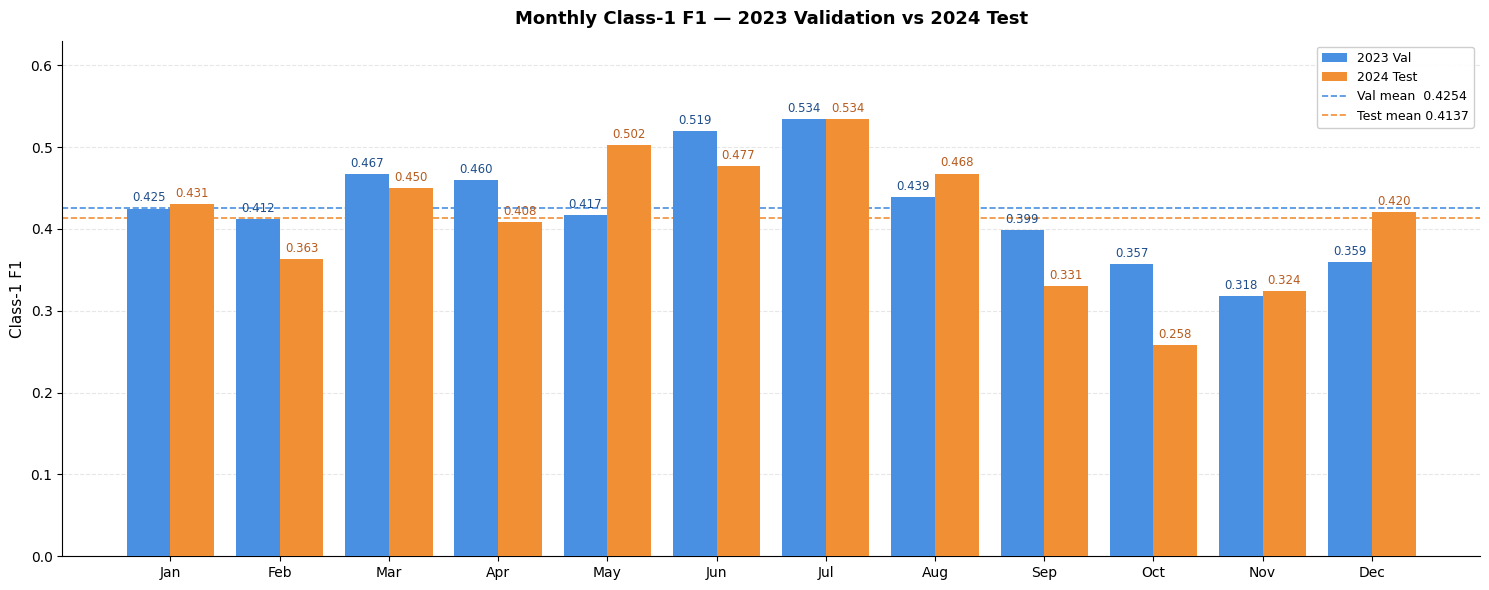

In [60]:
import matplotlib.pyplot as plt
import numpy as np

# Extract F1 values from both lists (index 1 in each tuple)
val_f1  = [r[1] for r in val_monthly_results]
test_f1 = [r[1] for r in test_monthly_results]

val_mean  = sum(val_f1)  / len(val_f1)
test_mean = sum(test_f1) / len(test_f1)

months       = np.arange(1, 13)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Build chart
fig, ax = plt.subplots(figsize=(15, 6))

bar_width = 0.4
x_val  = months - bar_width/2
x_test = months + bar_width/2

bars_val  = ax.bar(x_val,  val_f1,  bar_width, color='#4A90E2', label='2023 Val',  zorder=3)
bars_test = ax.bar(x_test, test_f1, bar_width, color='#F18F35', label='2024 Test', zorder=3)

# Mean lines
ax.axhline(val_mean,  linestyle='--', color='#4A90E2', linewidth=1.2,
           label=f'Val mean  {val_mean:.4f}', zorder=2)
ax.axhline(test_mean, linestyle='--', color='#F18F35', linewidth=1.2,
           label=f'Test mean {test_mean:.4f}', zorder=2)

# Value labels above each bar
for bars, color in [(bars_val, '#1F4E8B'), (bars_test, '#B85B1F')]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.005,
                f'{height:.3f}', ha='center', va='bottom',
                fontsize=8.5, color=color)

# Styling
ax.set_title('Monthly Class-1 F1 — 2023 Validation vs 2024 Test',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Class-1 F1', fontsize=11)
ax.set_xticks(months)
ax.set_xticklabels(month_labels)
ax.set_ylim(0, max(max(val_f1), max(test_f1)) * 1.18)
ax.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)
ax.set_axisbelow(True)

# Reorder legend: mean lines first, then bars
handles, labels = ax.get_legend_handles_labels()
order = [2, 3, 0, 1]
ax.legend([handles[i] for i in order], [labels[i] for i in order],
          loc='upper right', framealpha=0.95, fontsize=9)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('monthly_f1_val_vs_test.png', dpi=150, bbox_inches='tight')
plt.show()

## Precision Recall Curve

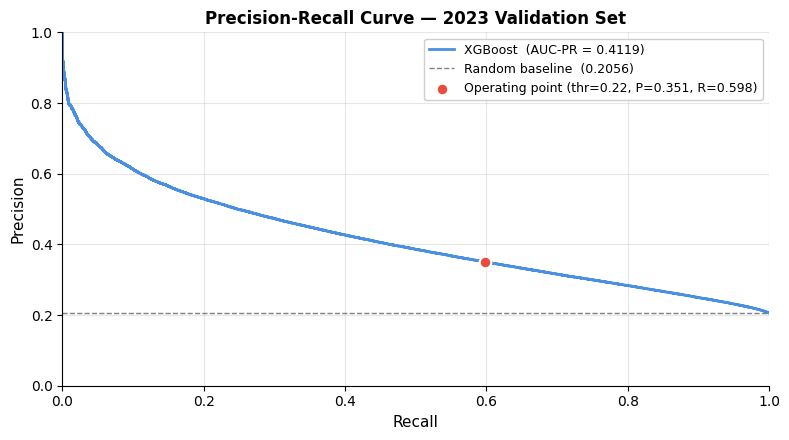


📊 Precision-Recall Summary
  Model        : XGBoost
  Set          : 2023 Validation Set
  AUC-PR       : 0.4119
  Baseline     : 0.2056  (= class prevalence)
  Lift         : 2.00× over random

  @ Threshold = 0.22:
    Precision  : 0.3506
    Recall     : 0.5982


In [61]:
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
from sklearn.metrics import precision_recall_curve, average_precision_score

# ============================================================
# CONFIG
# ============================================================
MODEL          = model              # trained Spark pipeline model
DF             = df_val_sampled     # validation DataFrame
TARGET_COL     = 'ArrDel15'
THRESHOLD      = 0.22               # chosen operating threshold
MODEL_NAME     = 'XGBoost'
SET_LABEL      = '2023 Validation Set'

# ============================================================
# STEP 1: Score the data and extract P(class=1)
# ============================================================
extract_p1 = F.udf(lambda v: float(v[1]), DoubleType())

scored = (
    MODEL.transform(DF)
         .withColumn('p1', extract_p1('probability'))
         .select(TARGET_COL, 'p1')
)

# Pull to pandas for sklearn (sample if too large)
pdf = scored.toPandas()
y_true  = pdf[TARGET_COL].astype(int).values
y_proba = pdf['p1'].values

# ============================================================
# STEP 2: Compute PR curve and AUC
# ============================================================
precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
auc_pr     = average_precision_score(y_true, y_proba)
base_rate  = y_true.mean()

# ============================================================
# STEP 3: Find operating point at chosen threshold
# ============================================================
y_pred_at_thr = (y_proba >= THRESHOLD).astype(int)
tp = ((y_pred_at_thr == 1) & (y_true == 1)).sum()
fp = ((y_pred_at_thr == 1) & (y_true == 0)).sum()
fn = ((y_pred_at_thr == 0) & (y_true == 1)).sum()

op_precision = tp / (tp + fp) if (tp + fp) else 0
op_recall    = tp / (tp + fn) if (tp + fn) else 0

# ============================================================
# STEP 4: Plot
# ============================================================
fig, ax = plt.subplots(figsize=(8, 4.5))

# Main curve
ax.plot(recall, precision, linewidth=2, color='#4A90E2',
        label=f'{MODEL_NAME}  (AUC-PR = {auc_pr:.4f})')

# Random baseline
ax.axhline(base_rate, linestyle='--', color='gray', linewidth=1,
           label=f'Random baseline  ({base_rate:.4f})')

# Operating point marker
ax.scatter(op_recall, op_precision, s=70, color='#E74C3C', zorder=5, edgecolor='white',
           linewidth=1.5,
           label=f'Operating point (thr={THRESHOLD}, P={op_precision:.3f}, R={op_recall:.3f})')

# Styling
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title(f'Precision-Recall Curve — {SET_LABEL}',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 1.0)
ax.grid(alpha=0.3, linestyle='-')
ax.set_axisbelow(True)

# Legend
ax.legend(loc='upper right', fontsize=9, framealpha=0.95)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('pr_curve_validation.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# STEP 5: Print summary
# ============================================================
print(f"\n📊 Precision-Recall Summary")
print(f"  Model        : {MODEL_NAME}")
print(f"  Set          : {SET_LABEL}")
print(f"  AUC-PR       : {auc_pr:.4f}")
print(f"  Baseline     : {base_rate:.4f}  (= class prevalence)")
print(f"  Lift         : {auc_pr / base_rate:.2f}× over random")
print(f"\n  @ Threshold = {THRESHOLD}:")
print(f"    Precision  : {op_precision:.4f}")
print(f"    Recall     : {op_recall:.4f}")

# Weather Flag Lift Analysis

In [62]:
from pyspark.sql import functions as F
import pandas as pd

# Configuration
WEATHER_FLAGS = [
    'origin_is_rain', 'origin_is_snow', 'origin_is_fog',
    'origin_low_visibility', 'origin_high_wind', 'origin_severe_weather',
    'dest_is_rain', 'dest_is_snow', 'dest_is_fog',
    'dest_low_visibility', 'dest_high_wind', 'dest_severe_weather',
]
TARGET = 'ArrDel15'
YEARS = [2018, 2019, 2020, 2021, 2022, 2023, 2024]

# Load the full data (or use the union of the splits)
df_full = (
    spark.read.parquet(train_file_path)
    .unionByName(spark.read.parquet(validate_file_path))
    .unionByName(spark.read.parquet(test_file_path))
)

# Compute per (year, flag) lift
results = []
for year in YEARS:
    df_y = df_full.filter(F.col('Year') == year)

    # Yearly base rate
    base_row = df_y.agg(
        F.avg(F.col(TARGET).cast('double')).alias('base'),
        F.count('*').alias('n_total')
    ).collect()[0]
    base_rate = base_row['base']
    n_total = base_row['n_total']

    if base_rate is None:
        continue

    # For each flag, compute delay rate when flag = 1
    for flag in WEATHER_FLAGS:
        flag_stats = df_y.filter(F.col(flag) == 1).agg(
            F.avg(F.col(TARGET).cast('double')).alias('delay_rate'),
            F.count('*').alias('n_flagged')
        ).collect()[0]

        if flag_stats['n_flagged'] is None or flag_stats['n_flagged'] == 0:
            continue

        results.append({
            'Year': year,
            'Feature': flag,
            'base_rate': base_rate,
            'flag_delay_rate': flag_stats['delay_rate'],
            'delta_pp': (flag_stats['delay_rate'] - base_rate) * 100,   # percentage points
            'lift_ratio': flag_stats['delay_rate'] / base_rate,
            'n_flagged': flag_stats['n_flagged'],
            'n_total': n_total,
            'prevalence_pct': flag_stats['n_flagged'] / n_total * 100,
        })

lift_df = pd.DataFrame(results)
print(lift_df.head(20))

    Year                Feature  base_rate  flag_delay_rate   delta_pp  \
0   2018         origin_is_rain   0.191214         0.300688  10.947328   
1   2018         origin_is_snow   0.191214         0.427615  23.640038   
2   2018          origin_is_fog   0.191214         0.258146   6.693219   
3   2018  origin_low_visibility   0.191214         0.324686  13.347168   
4   2018       origin_high_wind   0.191214         0.298913  10.769854   
5   2018  origin_severe_weather   0.191214         0.299158  10.794361   
6   2018           dest_is_rain   0.191214         0.298110  10.689614   
7   2018           dest_is_snow   0.191214         0.302720  11.150533   
8   2018            dest_is_fog   0.191214         0.251415   6.020086   
9   2018    dest_low_visibility   0.191214         0.292675  10.146072   
10  2018         dest_high_wind   0.191214         0.284599   9.338440   
11  2018    dest_severe_weather   0.191214         0.286231   9.501631   
12  2019         origin_is_rain   0.19

In [63]:
# Pivot: feature × year showing delta (percentage point lift)
pivot_delta = (
    lift_df.pivot(index='Feature', columns='Year', values='delta_pp')
           .round(1)
)

# Add average across all years for sorting
pivot_delta['Mean Δ'] = pivot_delta.mean(axis=1).round(1)
pivot_delta = pivot_delta.sort_values('Mean Δ', ascending=False)

print("\n📈 Delta (percentage points above base rate) by feature × year:\n")
print(pivot_delta.to_string())


📈 Delta (percentage points above base rate) by feature × year:

Year                   2018  2019  2020  2021  2022  2023  2024  Mean Δ
Feature                                                                
origin_is_snow         23.6  28.7  25.3  19.5  27.2  23.2  27.6    25.0
origin_low_visibility  13.3  15.9  12.6   9.2  13.8  11.7  12.7    12.7
dest_is_snow           11.2  15.7  13.5   6.2  14.3  10.1  13.2    12.0
origin_severe_weather  10.8  11.5   6.8   7.2   9.3   9.0   9.5     9.2
origin_is_rain         10.9  10.8   5.8   8.5   9.1   9.4   9.6     9.2
dest_low_visibility    10.1  12.3   9.4   6.3   9.2   8.2   8.2     9.1
dest_is_rain           10.7  11.1   5.6   8.5   8.9   8.7   9.4     9.0
origin_high_wind       10.8  12.1   5.3   5.0   8.6   8.8   9.6     8.6
dest_severe_weather     9.5  10.3   5.6   6.1   7.6   7.3   8.0     7.8
dest_high_wind          9.3  11.2   4.7   4.1   6.8   7.5   8.3     7.4
origin_is_fog           6.7   7.4   5.9   3.8   5.4   5.9   6.3     5.9

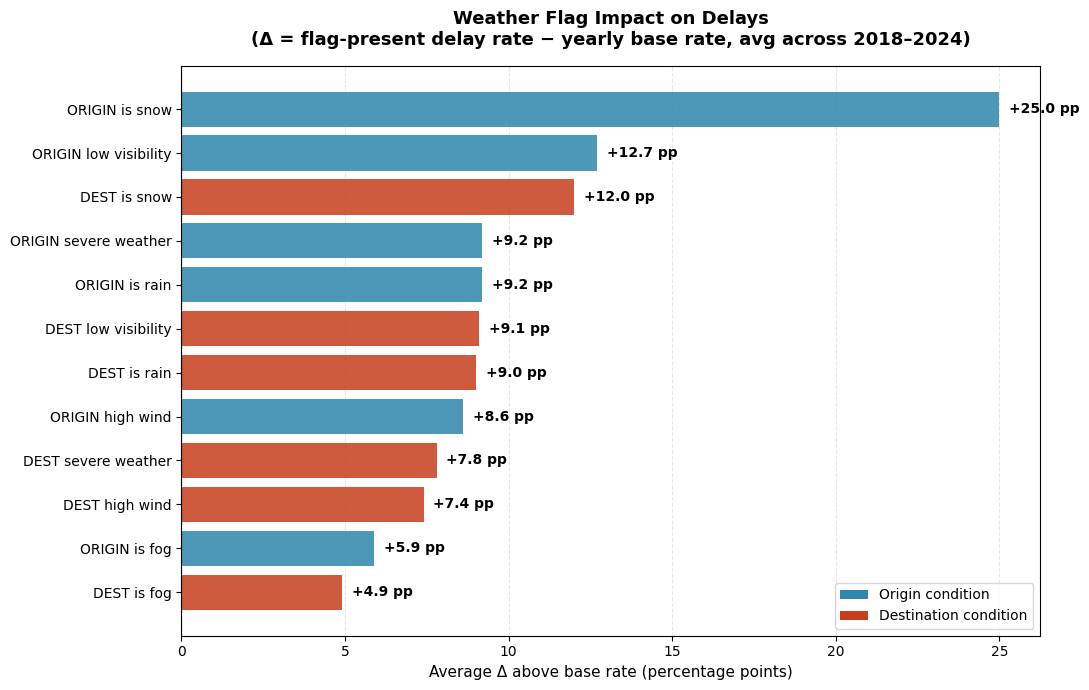

In [64]:
fig, ax = plt.subplots(figsize=(11, 7))

features_clean = [f.replace('_', ' ').replace('origin', 'ORIGIN').replace('dest', 'DEST')
                  for f in pivot_delta.index]
mean_deltas = pivot_delta['Mean Δ'].values

# Color by origin vs dest
colors = ['#2E86AB' if 'ORIGIN' in f else '#C73E1D' for f in features_clean]

bars = ax.barh(features_clean, mean_deltas, color=colors, alpha=0.85)

# Value labels
for bar, val in zip(bars, mean_deltas):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'+{val:.1f} pp', va='center', fontsize=10, fontweight='bold')

# Baseline reference
ax.axvline(0, color='black', linewidth=0.8)

ax.set_xlabel('Average Δ above base rate (percentage points)', fontsize=11)
ax.set_title('Weather Flag Impact on Delays\n(Δ = flag-present delay rate − yearly base rate, avg across 2018–2024)',
             fontsize=13, fontweight='bold', pad=15)

# Custom legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#2E86AB', label='Origin condition'),
    Patch(facecolor='#C73E1D', label='Destination condition'),
], loc='lower right')

ax.invert_yaxis()  # Largest at top
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('weather_flag_lift_bar.png', dpi=150, bbox_inches='tight')
plt.show()